In [ ]:
# Lista de Exercícios – Análise Exploratória dos Dados

!pip install gdown
import pandas as pd
import gdown

GDRIVE_FILE_ID = '1SuGNScn_qINErSYFCYS_7hPWZD5hFTKa'
OUTPUT_FILENAME = 'BOVA11_neghist_20_25.csv'

try:
    gdown.download(id=GDRIVE_FILE_ID, output=OUTPUT_FILENAME, quiet=False)
    print(f"File '{OUTPUT_FILENAME}' downloaded successfully!")

    dataset = pd.read_csv(OUTPUT_FILENAME, sep=';', on_bad_lines='warn')
    print("Dataset 'BOVA11_neghist_20_25.csv' loaded successfully!")
    display(dataset.head())

except Exception:
    raise

Downloading...
From: https://drive.google.com/uc?id=1SuGNScn_qINErSYFCYS_7hPWZD5hFTKa
To: /content/BOVA11_neghist_20_25.csv
100%|██████████| 59.4M/59.4M [00:00<00:00, 223MB/s]


File 'BOVA11_neghist_20_25.csv' downloaded successfully!
Dataset 'BOVA11_neghist_20_25.csv' loaded successfully!


,tipo_registro,data_referencia,cod_bdi,cod_negociacao,tipo_mercado,nome_empresa,especificacao,num_dias_mercado_termo,cod_moeda,preco_abertura,...,qtd_negocios,qtd_titulos_negociados,volume_titulos_negociados,preco_exercicio,indicador_correcao_preco_exercicio,data_vencimento,fator_cot,preco_exercicio_pontos,cod_isin,num_dist
0,1,20251223,14,BOVA11,10,ISHARES BOVA,CI,NaN,R$,"155,82",...,34996,4205277,"660117724,37",0,0,99991231,1,0,BRBOVACTF003,116
1,1,20251223,62,BOVA11T,30,ISHARES BOVA,CI,90.0,R$,"162,37",...,6,7005,"1139535,42",0,0,99991231,1,0,BRBOVACTF003,116
2,1,20251223,62,BOVA11T,30,ISHARES BOVA,CI,120.0,R$,"164,49",...,2,1620,"266477,06",0,0,99991231,1,0,BRBOVACTF003,116
3,1,20251223,78,BOVAA1,70,BOVAE,CI,0.0,R$,"0,38",...,313,318187,"126681,04",165,0,20260116,1,0,BRBOVACTF003,115
4,1,20251223,78,BOVAA10,70,BOVA,CI,0.0,R$,"57,1",...,5,5147,"294728,3",100,0,20260116,1,0,BRBOVACTF003,110


In [ ]:
# 1) Considere o dataset selecionado. Faça a caracterização inicial dos principais tipos dos atributos e avalie as Medidas de Localidade.

import pandas as pd
import numpy as np
from IPython.display import display

df = dataset

cols_preco = ['preco_abertura','preco_max','preco_min','preco_med','preco_ult',
              'preco_melhor_oferta_compra','preco_melhor_oferta_venda',
              'volume_titulos_negociados','preco_exercicio']
for col in cols_preco:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', '.').str.strip(), errors='coerce'
    )

# ── 2. Caracterização dos atributos ─────────────────────────
attrs = [
    ('preco_abertura',                     'Numérico contínuo',  'float64'   ),
    ('preco_max',                          'Numérico contínuo',  'float64'   ),
    ('preco_min',                          'Numérico contínuo',  'float64'   ),
    ('preco_med',                          'Numérico contínuo',  'float64'   ),
    ('preco_ult',                          'Numérico contínuo',  'float64'   ),
    ('preco_melhor_oferta_compra',         'Numérico contínuo',  'float64'   ),
    ('preco_melhor_oferta_venda',          'Numérico contínuo',  'float64'   ),
    ('volume_titulos_negociados',          'Numérico contínuo',  'float64'   ),
    ('preco_exercicio',                    'Numérico contínuo',  'float64'   ),
    ('qtd_negocios',                       'Numérico discreto',  'int64'     ),
    ('qtd_titulos_negociados',             'Numérico discreto',  'int64'     ),
    ('num_dias_mercado_termo',             'Numérico discreto',  'float64*'  ),
    ('num_dist',                           'Numérico discreto',  'int64'     ),
    ('cod_bdi',                            'Categórico nominal', 'int64'     ),
    ('tipo_mercado',                       'Categórico nominal', 'int64'     ),
    ('cod_negociacao',                     'Categórico nominal', 'str'       ),
    ('cod_isin',                           'Categórico nominal', 'str'       ),
    ('cod_moeda',                          'Categórico nominal', 'str'       ),
    ('especificacao',                      'Categórico nominal', 'str'       ),
    ('nome_empresa',                       'Categórico nominal', 'str'       ),
    ('data_referencia',                    'Temporal',           'datetime64'),
    ('data_vencimento',                    'Temporal',           'datetime64'),
    ('tipo_registro',                      'Constante',          'int64'     ),
    ('fator_cot',                          'Constante',          'int64'     ),
    ('indicador_correcao_preco_exercicio', 'Constante',          'int64'     ),
    ('preco_exercicio_pontos',             'Constante',          'int64'     ),
]

tab1 = pd.DataFrame(attrs, columns=['Atributo', 'Tipo Estatístico', 'Tipo Python'])

print("=== TABELA 1 — CARACTERIZAÇÃO DOS ATRIBUTOS ===\n")
display(tab1)

# ── 3. Medidas de localidade ─────────────────────────────────
cols_analiticas = [
    'preco_abertura', 'preco_max', 'preco_min', 'preco_med', 'preco_ult',
    'preco_melhor_oferta_compra', 'preco_melhor_oferta_venda',
    'qtd_negocios', 'qtd_titulos_negociados', 'volume_titulos_negociados',
    'num_dias_mercado_termo', 'num_dist',
]

rows = []
for col in cols_analiticas:
    s = df[col].dropna()
    rows.append({
        'Coluna':        col,
        'N Válidos':     len(s),
        'N Nulos':       df[col].isnull().sum(),
        'Média':         s.mean(),
        'Mediana':       s.median(),
        'Moda':          float(s.mode().iloc[0]),
        'Desvio Padrão': s.std(),
        'Variância':     s.var(),
    })

tab2 = pd.DataFrame(rows).set_index('Coluna')

# ── Formatar cada coluna com precisão adequada ───────────────
pd.set_option('display.float_format', '{:.4f}'.format)

print("\n=== TABELA 2 — MEDIDAS DE LOCALIDADE ===\n")
display(tab2.style.format({
    'N Válidos':     '{:,.0f}',
    'N Nulos':       '{:,.0f}',
    'Média':         '{:,.4f}',
    'Mediana':       '{:,.4f}',
    'Moda':          '{:,.4f}',
    'Desvio Padrão': '{:,.4f}',
    'Variância':     '{:,.4f}',
}))

=== TABELA 1 — CARACTERIZAÇÃO DOS ATRIBUTOS ===



,Atributo,Tipo Estatístico,Tipo Python
0,preco_abertura,Numérico contínuo,float64
1,preco_max,Numérico contínuo,float64
2,preco_min,Numérico contínuo,float64
3,preco_med,Numérico contínuo,float64
4,preco_ult,Numérico contínuo,float64
5,preco_melhor_oferta_compra,Numérico contínuo,float64
6,preco_melhor_oferta_venda,Numérico contínuo,float64
7,volume_titulos_negociados,Numérico contínuo,float64
8,preco_exercicio,Numérico contínuo,float64
9,qtd_negocios,Numérico discreto,int64



=== TABELA 2 — MEDIDAS DE LOCALIDADE ===



,N Válidos,N Nulos,Média,Mediana,Moda,Desvio Padrão,Variância
Coluna,,,,,,,
preco_abertura,"473,995",0,8.9890,2.1400,0.0100,20.2314,409.3114
preco_max,"473,995",0,9.1885,2.4000,0.0100,20.2616,410.5310
preco_min,"473,995",0,8.7953,1.9000,0.0100,20.2049,408.2374
preco_med,"473,995",0,8.9800,2.1100,0.0100,20.2332,409.3804
preco_ult,"473,995",0,8.9876,2.1100,0.0100,20.2353,409.4662
preco_melhor_oferta_compra,"473,995",0,2.5627,0.0800,0.0000,8.5962,73.8953
preco_melhor_oferta_venda,"473,995",0,15.9147,0.0500,0.0000,"3,559.3873","12,669,238.0817"
qtd_negocios,"473,995",0,410.8095,10.0000,1.0000,"3,602.8345","12,980,416.7742"
qtd_titulos_negociados,"473,995",0,"176,754.5820","12,000.0000",1.0000,"662,697.6101","439,168,122,455.4667"


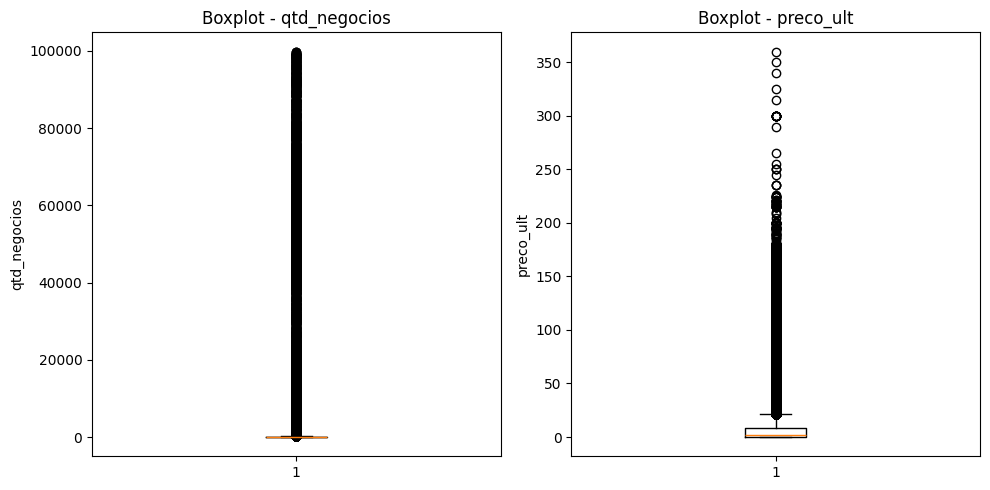

In [ ]:
# 2) Analise o espalhamento das observações dos atributos de pelo menos 2 atributos. Utilize técnicas gráficas como Boxplots para verificar a presença de outliers.
import matplotlib.pyplot as plt
columns = ['qtd_negocios', 'preco_ult']


data = dataset[columns].apply(
    lambda c: pd.to_numeric(c.astype(str).str.replace(',', '.', regex=False), errors='coerce') # preco_ult vem com vírgula decimal; garante valores numéricos
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, col in zip(axes, columns):
    ax.boxplot(data[col].dropna(), vert=True)
    ax.set_title(f'Boxplot - {col}')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()


Correlation: 0.2332
Covariance: 16998.3946


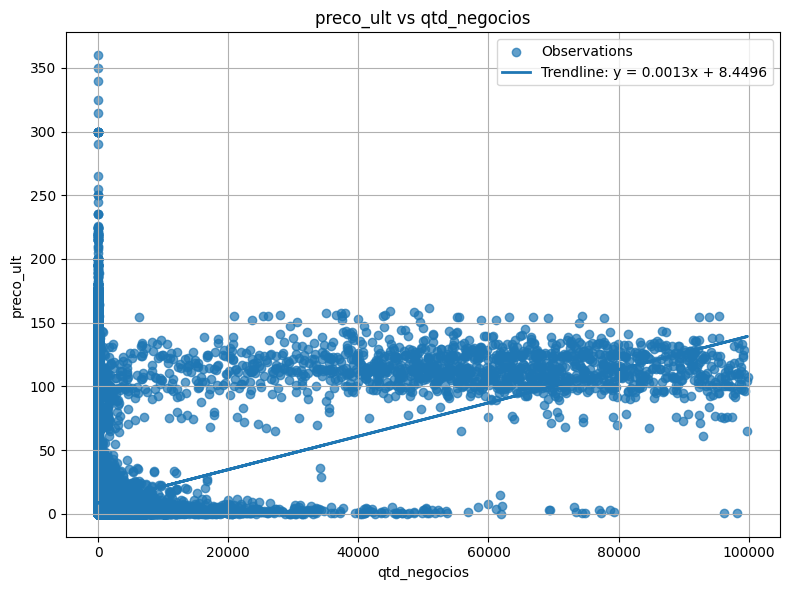

In [ ]:
# 3) Faça a análise de correlação e covariância entre os atributos.

vars = df[columns].dropna()

# Correlação'
correlation = vars['qtd_negocios'].corr(vars['preco_ult'])

# Covariance
covariance = vars['qtd_negocios'].cov(vars['preco_ult'])

print(f"Correlation: {correlation:.4f}")
print(f"Covariance: {covariance:.4f}")

# Fit linear trendline
slope, intercept = np.polyfit(vars['qtd_negocios'], vars['preco_ult'], 1)

# Predicted values
trendline = slope * vars['qtd_negocios'] + intercept

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(vars['qtd_negocios'], vars['preco_ult'], alpha=0.7, label="Observations")
plt.plot(
    vars['qtd_negocios'],
    trendline,
    linewidth=2,
    label=f"Trendline: y = {slope:.4f}x + {intercept:.4f}"
)

plt.title(f"{'preco_ult'} vs {'qtd_negocios'}")
plt.xlabel('qtd_negocios')
plt.ylabel('preco_ult')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
